# Librerias

In [66]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Carga de la bbdd y reducción

## 1. Cargar csv

In [67]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260504.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [68]:
#Nos quedamos con las variables que usaremos para perfil de cliente
cols = ["age", "job", "marital", "education", "balance", "default", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  string
 2   marital    11162 non-null  string
 3   education  11162 non-null  string
 4   balance    11162 non-null  int64 
 5   default    11162 non-null  string
 6   housing    11162 non-null  string
 7   loan       11162 non-null  string
 8   deposit    11162 non-null  string
dtypes: int64(2), string(7)
memory usage: 1.1 MB


# 2. Categorizar edad

In [69]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

# 3. Categorizar multiproducto

In [70]:
#Crear variables binarias 0/1 para cada producto
df_perfil = df_perfil.copy()

df_perfil["deposit_bin"] = (df_perfil["deposit"] == "yes").astype(int)
df_perfil["loan_bin"] = (df_perfil["loan"] == "yes").astype(int)
df_perfil["housing_bin"] = (df_perfil["housing"] == "yes").astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1


In [71]:
#Crear variable combinación, según orden de 0 y 1 se puede saber que productos
def multiproducto(row):
    return f"{row['deposit_bin']}{row['loan_bin']}{row['housing_bin']}"

df_perfil["multiproducto"] = df_perfil.apply(multiproducto, axis=1)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101


In [72]:
#Crear columna catagorica de multiproducto:
etiquetas = {
    "000": "Ningún producto",
    "100": "Solo depósitos",
    "010": "Solo préstamos",
    "001": "Solo hipotecas",
    "110": "Depósitos y préstamos",
    "101": "Depósitos y hipotecas",
    "011": "Préstamos y hipotecas",
    "111": "Todos los productos"
}

df_perfil['multiproducto_cat'] = df_perfil['multiproducto'].astype(str).map(etiquetas)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas


In [73]:
#Crear columna conteo de productos:
df_perfil["cantidad_prod"] = df_perfil["deposit_bin"] + df_perfil["loan_bin"] + df_perfil["housing_bin"]

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2


In [74]:
#Crear columna multiproducto binaria:
df_perfil["multiproducto_bin"] = (df_perfil["cantidad_prod"] > 1).astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2,1


# 4. Clústering

In [75]:
#dataset para modelo:
cols_modelo = ["age_group", "job", "marital", "education"]
df_perfil_m = df_perfil[cols_modelo].copy()
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

#Entrenar modelo:
k_opt = 5
km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

#Añadir columna clúster a dataset original:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5641
1    1781
2    1233
3    1014
4    1493
Name: count, dtype: int64

In [76]:
#Centroides:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

In [77]:
# Moda por clúster
multiproducto_moda = (
    df_perfil.groupby("cluster")["multiproducto_cat"]
    .agg(lambda x: x.mode().iloc[0])
    .sort_index()
)

# Centroides del modelo
perfil_clusters = pd.DataFrame(
    km.cluster_centroids_,
    columns=cols_modelo,
    index=[f"Cluster {i}" for i in range(km.n_clusters)]
)

# Añadir moda
perfil_clusters["multiproducto_moda"] = multiproducto_moda.values

perfil_clusters

,age_group,job,marital,education,multiproducto_moda
Cluster 0,26-35,management,married,secondary,Solo depósitos
Cluster 1,36-45,technician,single,tertiary,Solo depósitos
Cluster 2,46-55,technician,married,tertiary,Solo depósitos
Cluster 3,46-55,administration,single,secondary,Solo depósitos
Cluster 4,36-45,blue-collar,married,primary,Solo hipotecas


In [78]:
#Nos quedamos con variables para estudiar productos
cols_prod = ["cluster", "age_group", "job", "marital", "education", "balance","deposit", "loan", "housing", "default", "multiproducto", "multiproducto_cat", "cantidad_prod", "multiproducto_bin"]

df_product = df_perfil[cols_prod].copy()

df_product.head(3)

,cluster,age_group,job,marital,education,balance,deposit,loan,housing,default,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,0,56-65,administration,married,secondary,2343,yes,no,yes,no,101,Depósitos y hipotecas,2,1
1,0,56-65,administration,married,secondary,45,yes,no,no,no,100,Solo depósitos,1,0
2,0,36-45,technician,married,secondary,1270,yes,no,yes,no,101,Depósitos y hipotecas,2,1


# 5. Análisis descriptivo

In [79]:
# Tabla de contingencia Clúster vs Multiproducto
resumen = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100
resumen


multiproducto_bin,0,1
cluster,,
0,74.703067,25.296933
1,76.530039,23.469961
2,80.859692,19.140308
3,72.485207,27.514793
4,75.619558,24.380442


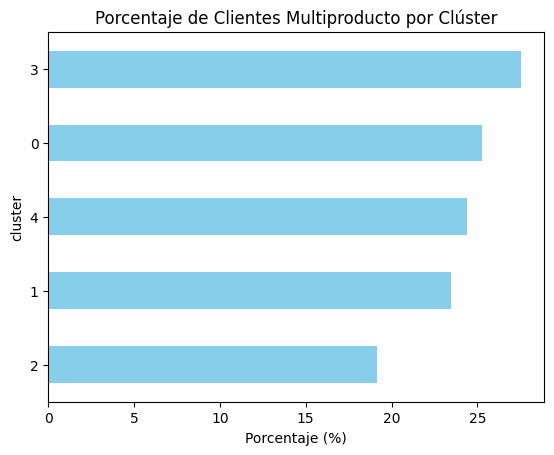

In [80]:
resumen[1].sort_values().plot(kind='barh', color='skyblue')
plt.title('Porcentaje de Clientes Multiproducto por Clúster')
plt.xlabel('Porcentaje (%)')
plt.show()

In [81]:
tabla = pd.crosstab(df_product['age_group'], df_product['multiproducto_bin'])
chi2, p, dof, expected = chi2_contingency(tabla)
print(p)

4.0609687058193257e-35


## Vision general

In [82]:

#Estadística descriptiva de la cantidad de productos
print("--- Estadísticas de Cantidad de Productos ---")
print(df_perfil['cantidad_prod'].describe())

# Media de productos por grupo de edad (Opcional pero muy útil)
print("\n--- Media de productos por Rango de Edad ---")
print(df_perfil.groupby('age_group')['cantidad_prod'].mean().sort_values(ascending=False))

--- Estadísticas de Cantidad de Productos ---
count    11162.000000
mean         1.077764
std          0.706600
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: cantidad_prod, dtype: float64

--- Media de productos por Rango de Edad ---
age_group
26-35    1.148724
<=25     1.124722
36-45    1.106262
46-55    0.998137
56-65    0.959484
65+      0.851759
Name: cantidad_prod, dtype: float64


C:\Users\misab\AppData\Local\Temp\ipykernel_15480\694409197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


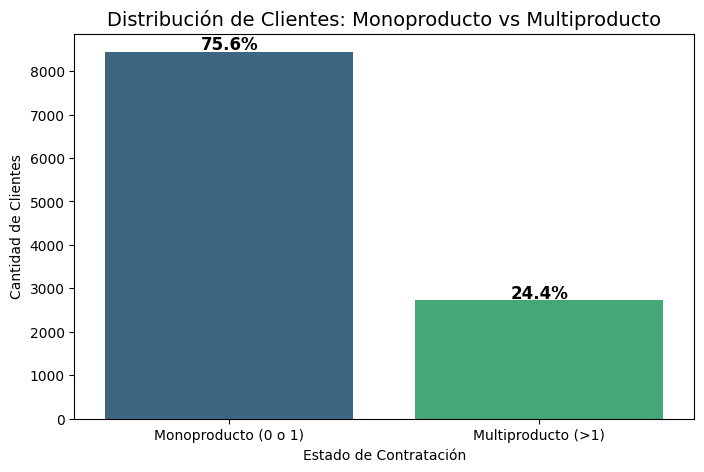

In [83]:
# Distribución de Multiproducto (Binario)
counts = df_perfil['multiproducto_bin'].value_counts()
percentages = df_perfil['multiproducto_bin'].value_counts(normalize=True) * 100

# gráfico de barras
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')

for i, p in enumerate(percentages):
    ax.annotate(f'{p:.1f}%', (i, counts.values[i] + 50), ha='center', fontsize=12, fontweight='bold')

plt.title('Distribución de Clientes: Monoproducto vs Multiproducto', fontsize=14)
plt.xticks([0, 1], ['Monoproducto (0 o 1)', 'Multiproducto (>1)'])
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Estado de Contratación')
plt.show()


## Análisis por combinaciones

C:\Users\misab\AppData\Local\Temp\ipykernel_15480\2048565418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


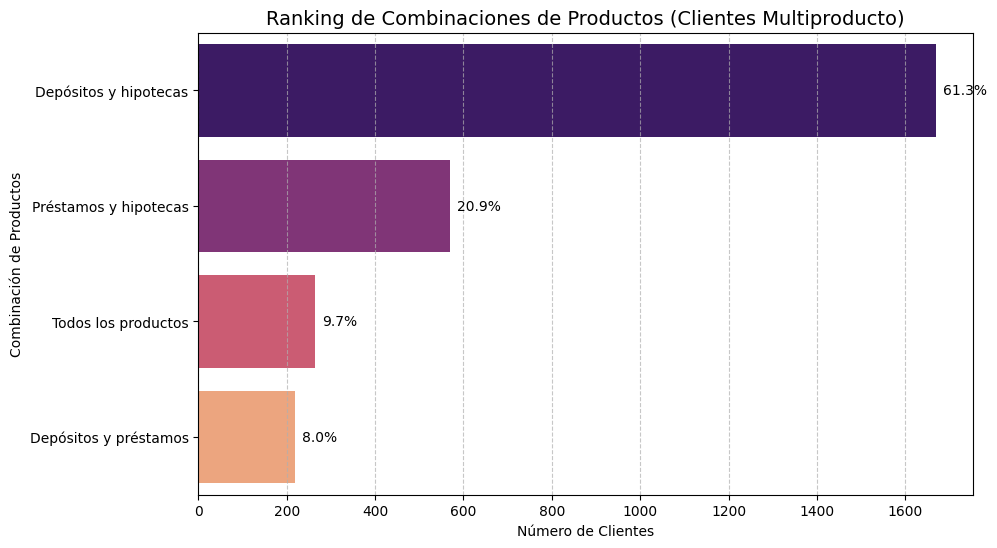

--- Detalle de Combinaciones ---
multiproducto_cat
Depósitos y hipotecas    1670
Préstamos y hipotecas     570
Todos los productos       265
Depósitos y préstamos     219
Name: count, dtype: int64


In [84]:
# 1. Filtrar solo a los clientes multiproducto para ver qué combinaciones tienen
df_multipro = df_perfil[df_perfil['multiproducto_bin'] == 1]

# 2. Conteo de combinaciones (usando la columna que ya creaste)
combinaciones_counts = df_multipro['multiproducto_cat'].value_counts()
combinaciones_percent = df_multipro['multiproducto_cat'].value_counts(normalize=True) * 100

# 3. Visualización de las combinaciones más frecuentes
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=combinaciones_counts.values, 
    y=combinaciones_counts.index, 
    palette='magma'
)

# Añadir etiquetas de porcentaje al final de cada barra
for i, p in enumerate(combinaciones_percent):
    ax.annotate(f'{p:.1f}%', (combinaciones_counts.values[i], i), 
                va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Ranking de Combinaciones de Productos (Clientes Multiproducto)', fontsize=14)
plt.xlabel('Número de Clientes')
plt.ylabel('Combinación de Productos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Tabla de resumen para el informe
print("--- Detalle de Combinaciones ---")
print(combinaciones_counts)

 ## Clúster vs multiproducto

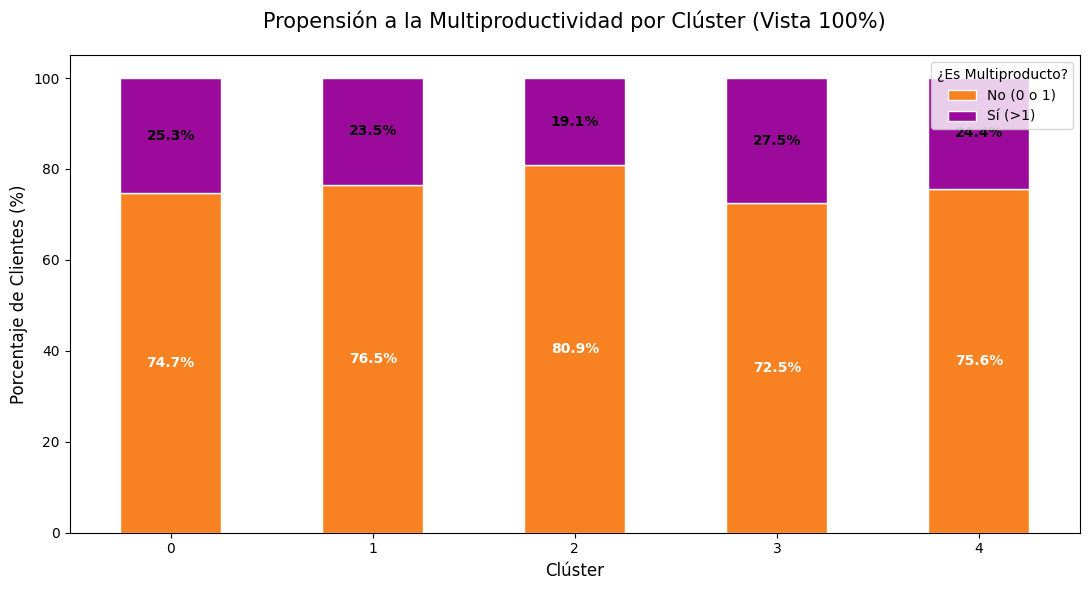

In [85]:
cross_tab = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100

# 2. Graficar barras apiladas
ax = cross_tab.plot(kind='bar', 
                    stacked=True, 
                    figsize=(11, 6), 
                    color=["#f88221", "#9C0A9C"], # Gris para monoproducto, Verde para multiproducto
                    edgecolor='white')


plt.title('Propensión a la Multiproductividad por Clúster (Vista 100%)', fontsize=15, pad=20)
plt.legend(title='¿Es Multiproducto?', labels=['No (0 o 1)', 'Sí (>1)'], loc='upper right')
plt.xlabel('Clúster', fontsize=12)
plt.ylabel('Porcentaje de Clientes (%)', fontsize=12)
plt.xticks(rotation=0)


for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Solo poner etiqueta si el segmento es lo suficientemente grande
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white' if height > 50 else 'black',
                fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis individual

C:\Users\misab\AppData\Local\Temp\ipykernel_15480\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\misab\AppData\Local\Temp\ipykernel_15480\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\misab\AppData\Local\Temp\ipykernel_15480\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')


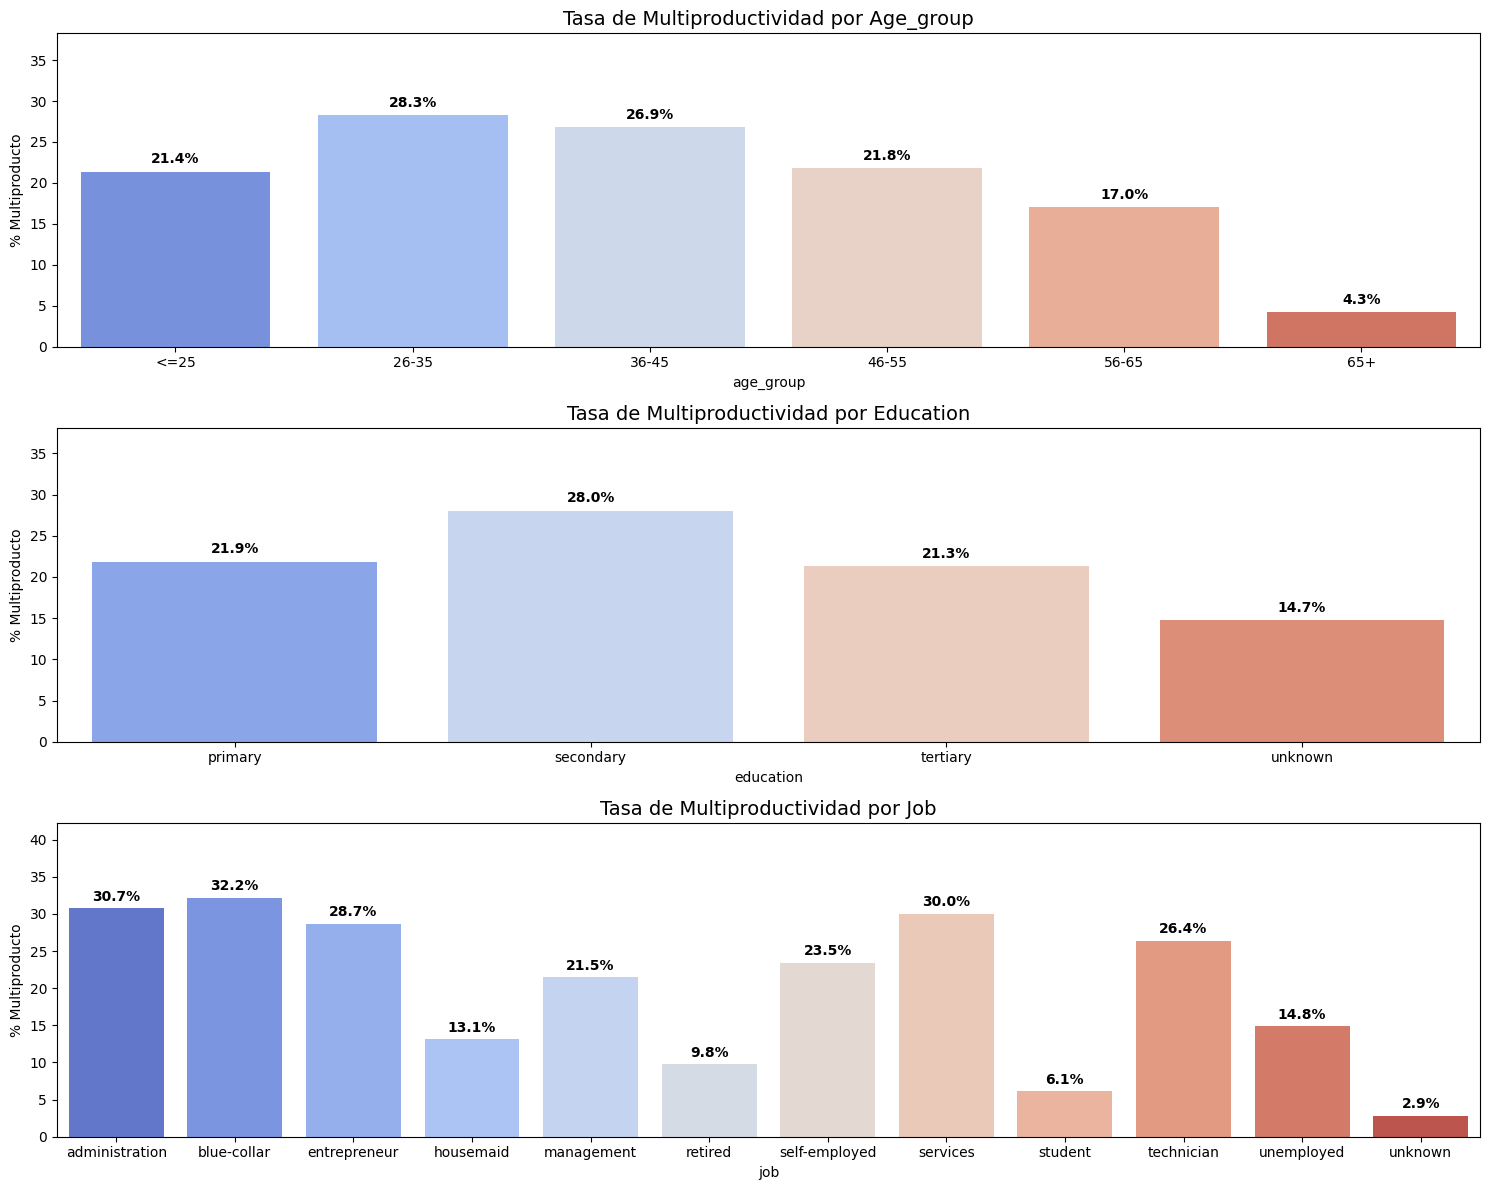

In [86]:
# Lista de variables demográficas a analizar
variables_demo = ['age_group', 'education', 'job']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_demo, 1):
    # Crear tabla de contingencia normalizada por variable
    tabla_var = pd.crosstab(df_perfil[var], df_perfil['multiproducto_bin'], normalize='index') * 100
    
    # Crear subgráfico
    plt.subplot(3, 1, i)
    # Graficamos solo la columna '1' (quienes sí son multiproducto)
    sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
    
    # Personalización
    plt.title(f'Tasa de Multiproductividad por {var.capitalize()}', fontsize=14)
    plt.ylabel('% Multiproducto')
    plt.xlabel(var)
    plt.ylim(0, max(tabla_var[1]) + 10) # Espacio para etiquetas
    
    # Añadir valores sobre las barras
    for index, value in enumerate(tabla_var[1]):
        plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Regresión logística binaria

In [87]:
#ver colinealidad variables:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_vars = ['age_group', 'education', 'job', 'marital']

cramer_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for col1 in categorical_vars:
    for col2 in categorical_vars:
        cramer_matrix.loc[col1, col2] = cramers_v(df_perfil[col1], df_perfil[col2])

print(cramer_matrix)


          age_group education       job   marital
age_group       1.0  0.157848  0.378213  0.353281
education  0.157848       1.0  0.462541  0.123964
job        0.378213  0.462541       1.0  0.234958
marital    0.353281  0.123964  0.234958       1.0


Eliminar del modelo job por posible colinealidad y muchas categorías

In [88]:
# 1. Reordenar categorías para que perfil profesionales consolidados sea la referencia

#Categoría del balance:
df_perfil['balance_bin'] = pd.qcut(df_perfil['balance'], q=4, labels=['bajo','medio','alto','muy_alto'])
df_perfil['balance_bin'] = df_perfil['balance_bin'].astype('category')
df_perfil['balance_bin'] = df_perfil['balance_bin'].cat.reorder_categories(
    ['muy_alto', 'bajo','medio','alto'], ordered=True)

# AGE GROUP
df_perfil['age_group'] = df_perfil['age_group'].astype('category')
df_perfil['age_group'] = df_perfil['age_group'].cat.reorder_categories(
    ['46-55', '<=25', '26-35', '36-45', '56-65', '65+'], ordered=True)

# EDUCATION
df_perfil['education'] = df_perfil['education'].astype('category')
df_perfil['education'] = df_perfil['education'].cat.reorder_categories(
    ['tertiary', 'primary', 'secondary', 'unknown'], ordered=True)

# MARITAL
df_perfil['marital'] = df_perfil['marital'].astype('category')
df_perfil['marital'] = df_perfil['marital'].cat.reorder_categories(
    ['married', 'divorced', 'single'], ordered=True)

# 2. Crear X e y
X = df_perfil[['age_group', 'education', 'marital', 'balance_bin']]
y = df_perfil['multiproducto_bin'].astype(float)

# 3. Crear dummies con tu perfil como referencia

X_dummies = pd.get_dummies(X, drop_first=True, dtype=float)

# Añadir constante
X_dummies = sm.add_constant(X_dummies)

# 4. Ajustar el modelo logístico

modelo = sm.Logit(y, X_dummies)
resultado = modelo.fit()

print(resultado.summary())

# Odds Ratios
odds_ratios = np.exp(resultado.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

# 5. Calcular probabilidad del perfil

# Como tu perfil es la categoría base, todas sus dummies = 0
perfil_base = {col: 0 for col in X_dummies.columns}
perfil_base['const'] = 1

perfil_base_df = pd.DataFrame([perfil_base])
prob_base = resultado.predict(perfil_base_df)[0]

print("\nProbabilidad del perfil base (46-55, married, tertiary, muy_alto):")
print(prob_base)

Optimization terminated successfully.
         Current function value: 0.541037
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      multiproducto_bin   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11148
Method:                           MLE   Df Model:                           13
Date:                Wed, 06 May 2026   Pseudo R-squ.:                 0.02638
Time:                        19:46:46   Log-Likelihood:                -6039.1
converged:                       True   LL-Null:                       -6202.7
Covariance Type:            nonrobust   LLR p-value:                 4.774e-62
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.6231      0.076    -21.285      0.000      -1.773      -1.474
ag

La probabilidad base (perfil de referencia) es:
Cliente de 46–55 años, casado, educación terciaria, saldo muy alto → 16.5%

1. Edad:
Comparado con 46–55:
26–35 → +57% más probable
36–45 → +35% más probable
≤25 → similar
56–65 → –27% menos probable
65+ → –84% menos probable
- Los jóvenes adultos (26–45) son los más multiproducto.  
- Los mayores de 65 son claramente los menos.

2. Educación:
Comparado con terciaria:
Secundaria → +44%
Primaria → +24%
Unknown → –24%
- Curiosamente, los niveles educativos más bajos tienen más multiproducto.

3. Estado civil
Comparado con casado:
Divorciado → +28%
Soltero → –16%
- Los divorciados son los más multiproducto.
- Los solteros son los menos.

4. Balance (tramos)
Comparado con “muy alto”:
Alto → +21%
Bajo → +19%
Medio → similar
- Los clientes con saldo “muy alto” NO son los más multiproducto.
- Los de saldo alto o bajo lo son más.

# Conclusión general del modelo

El multiproducto está más asociado a edad media (26–45)
También a educación baja o media
Y a divorciados
Y a clientes con saldo alto o bajo, no muy alto
- El perfil más multiproducto sería algo así:
Cliente de 26–35 años, divorciado, educación secundaria, saldo alto.

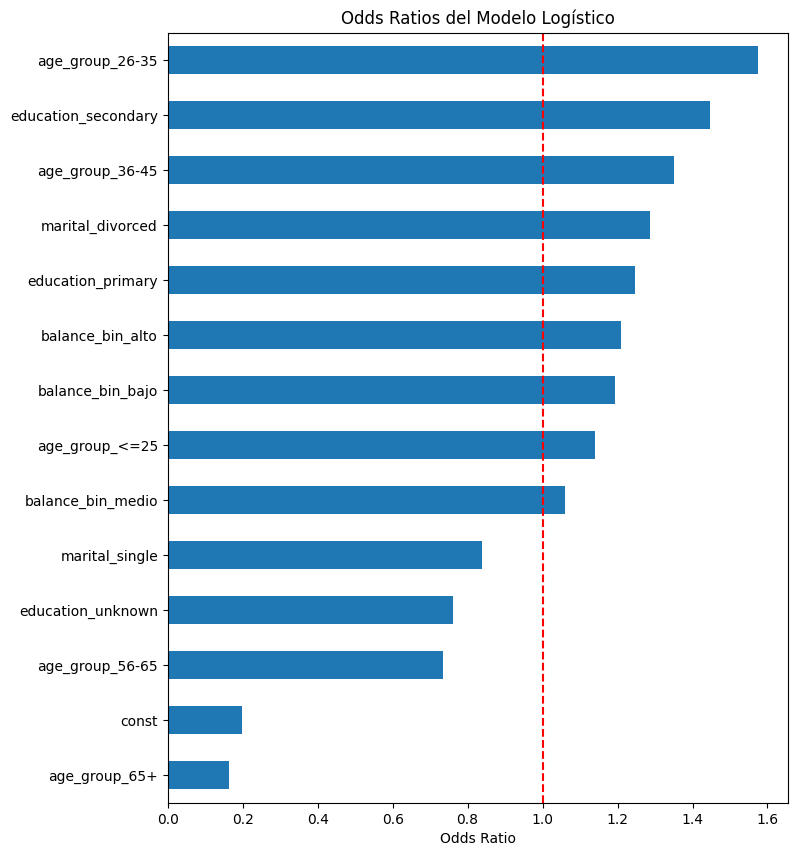

In [89]:
#Gráfico odds

odds = np.exp(resultado.params).sort_values()

plt.figure(figsize=(8,10))
odds.plot(kind='barh')
plt.title("Odds Ratios del Modelo Logístico")
plt.xlabel("Odds Ratio")
plt.axvline(1, color='red', linestyle='--')
plt.show()

        Logit Marginal Effects       
Dep. Variable:      multiproducto_bin
Method:                          dydx
At:                           overall
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
age_group_<=25          0.0237      0.024      0.977      0.329      -0.024       0.071
age_group_26-35         0.0816      0.012      6.661      0.000       0.058       0.106
age_group_36-45         0.0539      0.012      4.505      0.000       0.030       0.077
age_group_56-65        -0.0556      0.017     -3.206      0.001      -0.090      -0.022
age_group_65+          -0.3264      0.046     -7.148      0.000      -0.416      -0.237
education_primary       0.0395      0.014      2.834      0.005       0.012       0.067
education_secondary     0.0664      0.009      7.279      0.000       0.049       0.084
education_unknown      -0.0489      0.024     -2.019    

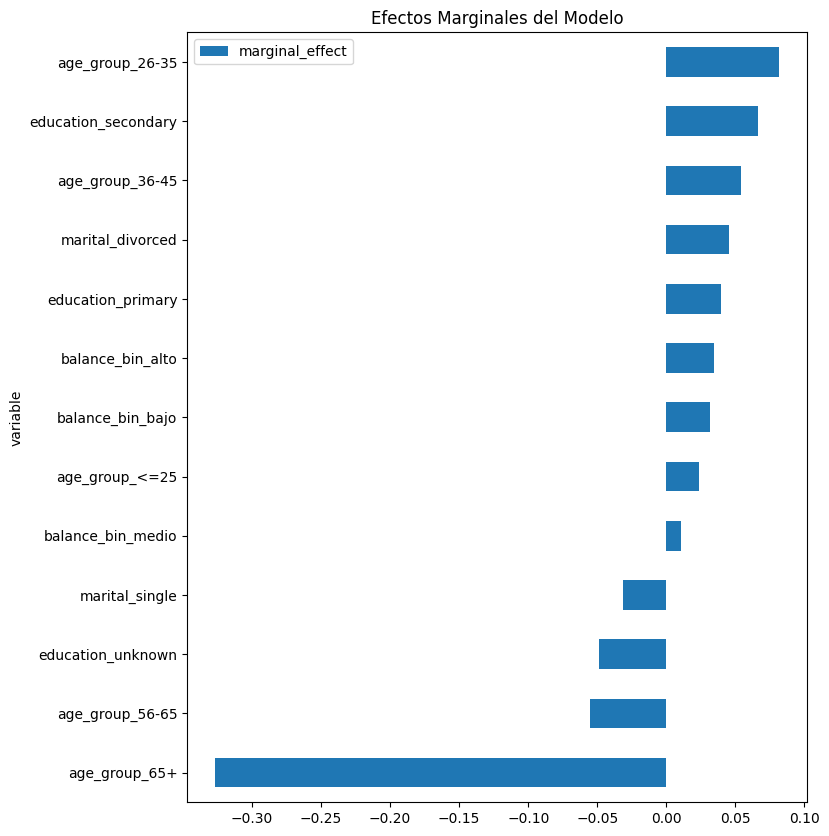

In [90]:
#Efectos marginales
mfx = resultado.get_margeff()
print(mfx.summary())

mfx_df = pd.DataFrame({
    'variable': mfx.summary_frame().index,
    'marginal_effect': mfx.margeff
})

mfx_df.sort_values('marginal_effect').plot(
    x='variable', y='marginal_effect', kind='barh', figsize=(8,10)
)
plt.title("Efectos Marginales del Modelo")
plt.show()

In [92]:
params = resultado.params
conf = resultado.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
print(np.exp(conf))

                         2.5%     97.5%  Odds Ratio
const                0.169901  0.229094    0.197290
age_group_<=25       0.875880  1.485755    1.140764
age_group_26-35      1.377032  1.801953    1.575229
age_group_36-45      1.184328  1.538700    1.349936
age_group_56-65      0.607044  0.886757    0.733689
age_group_65+        0.098619  0.267647    0.162465
education_primary    1.069959  1.450192    1.245650
education_secondary  1.309172  1.599591    1.447114
education_unknown    0.584424  0.992157    0.761473
marital_divorced     1.118863  1.477367    1.285680
marital_single       0.752928  0.936451    0.839690
balance_bin_bajo     1.050778  1.353641    1.192634
balance_bin_medio    0.931408  1.205011    1.059414
balance_bin_alto     1.065890  1.373767    1.210076


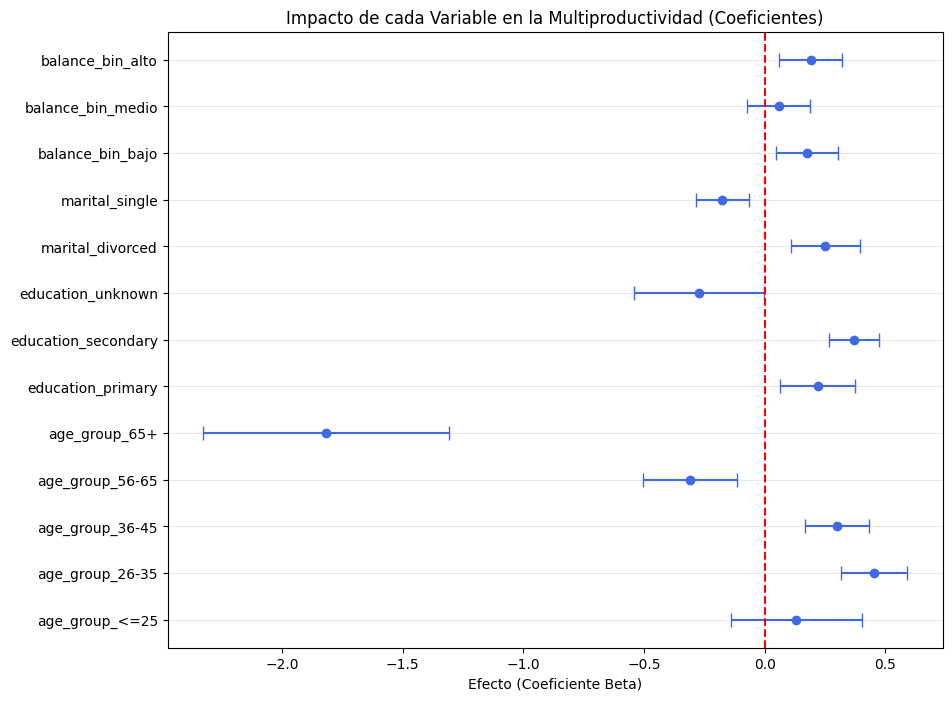

In [93]:
# Extraer coeficientes e intervalos de confianza
df_res = pd.DataFrame({
    'coef': resultado.params,
    'error': resultado.bse,
    'p_valor': resultado.pvalues
})
# Quitamos la constante para que no arruine la escala del gráfico
df_res = df_res.drop('const')

# Graficar
plt.figure(figsize=(10, 8))
plt.errorbar(df_res['coef'], df_res.index, xerr=2*df_res['error'], fmt='o', color='royalblue', capsize=5)
plt.axvline(x=0, color='red', linestyle='--') # Línea de neutralidad
plt.title('Impacto de cada Variable en la Multiproductividad (Coeficientes)')
plt.xlabel('Efecto (Coeficiente Beta)')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\misab\AppData\Local\Temp\ipykernel_15480\781651245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')


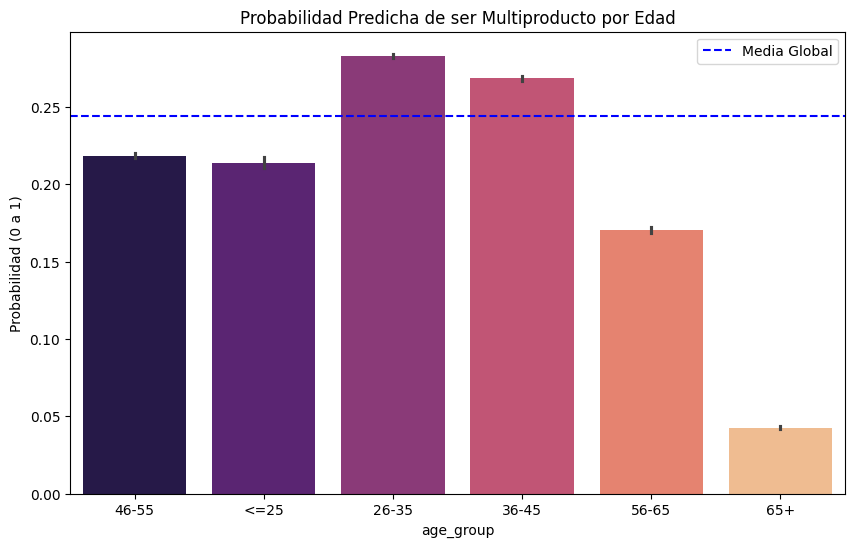

In [94]:
# Generar las probabilidades predichas del modelo
df_perfil['prob_predicha'] = resultado.predict(X_dummies)

# Graficar la probabilidad promedio por grupo de edad
plt.figure(figsize=(10, 6))
sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')
plt.title('Probabilidad Predicha de ser Multiproducto por Edad')
plt.ylabel('Probabilidad (0 a 1)')
plt.axhline(df_perfil['multiproducto_bin'].mean(), color='blue', linestyle='--', label='Media Global')
plt.legend()
plt.show()

# 7. Conclusiones